<a href="https://colab.research.google.com/github/biruk50/Medium_articles/blob/main/Three_coloring_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Generate Random Graph

### Subtask:
Generate a random undirected graph using a library like networkx. Specify a reasonable number of nodes and edges.

**Reasoning**:
To generate a random directed graph, I will first import the `networkx` library, then define the number of nodes and edges, create the graph using `nx.gnm_random_graph`, and finally print its basic properties.



In [ ]:
import networkx as nx

# Define the number of nodes and edges
num_nodes = 10
num_edges = 30

# Create a random undirected graph
G = nx.gnm_random_graph(num_nodes, num_edges)

# Print basic information about the generated graph
print(f"Generated a random undirected graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Generated a random undirected graph with 10 nodes and 30 edges.


In [ ]:
print("Nodes of graph G:", G.nodes())
print("Edges of graph G:", G.edges())

Nodes of graph G: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Edges of graph G: [(0, 6), (0, 2), (0, 3), (0, 7), (0, 9), (0, 4), (0, 1), (1, 9), (1, 6), (1, 5), (1, 8), (1, 3), (2, 7), (2, 4), (2, 5), (2, 3), (3, 9), (3, 6), (3, 8), (3, 5), (3, 7), (3, 4), (4, 7), (4, 9), (5, 8), (5, 7), (5, 6), (6, 9), (7, 8), (8, 9)]


## Initial Graph Visualization

### Subtask:
Visualize the generated random graph with its nodes and edges using networkx and matplotlib. Ensure a clear layout for readability.


**Reasoning**:
To visualize the generated graph, I will import `matplotlib.pyplot` and then use `nx.draw_networkx` to plot the graph with specified parameters for clear readability.



/usr/local/lib/python3.12/dist-packages/networkx/drawing/nx_pylab.py:1353: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)


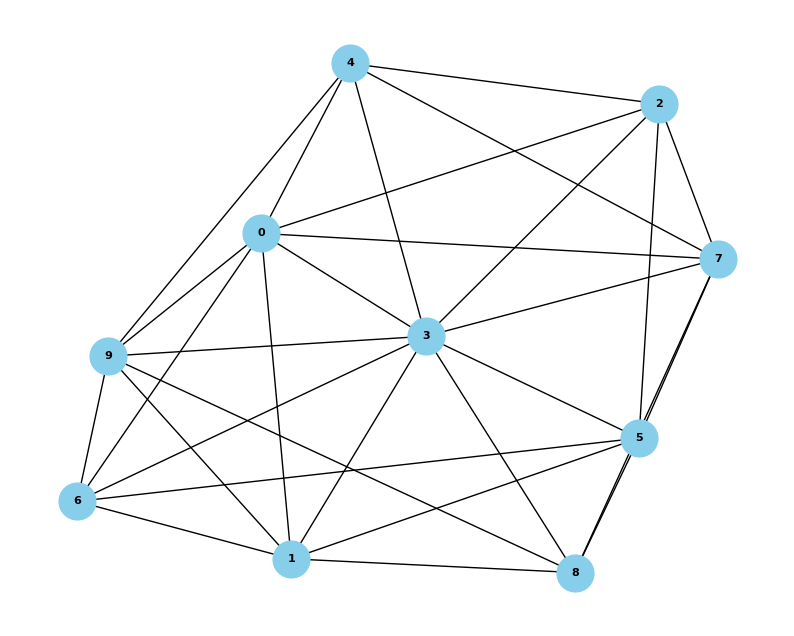

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and axes for the plot
plt.figure(figsize=(10, 8))

# Draw the graph
nx.draw_networkx(G, with_labels=True, arrowstyle='->', arrowsize=10, node_size=700, node_color='skyblue', font_size=8, font_weight='bold')

# Ensure the plot has no axes
plt.axis('off')

# Display the plot
plt.show()


In [ ]:
from collections import deque
import networkx as nx


def bfs_find_smallest_cycles(graph):
    node_info = {
        node: {'cycle': None, 'visited': 0, 'color': 0, 'Available': {1, 2, 3} }
        for node in graph.nodes()
    }

    cycles = {}
    cycle_counter = 0

    def extract_cycle_path(u, v, parent):
        path_u = []
        while u is not None:
            path_u.append(u)
            u = parent.get(u)

        path_v = []
        while v is not None:
            path_v.append(v)
            v = parent.get(v)

        set_u = set(path_u)
        lca = next((x for x in path_v if x in set_u), None)

        path1 = []
        x = path_u[0]
        while x != lca:
            path1.append(x)
            x = parent[x]
        path1.append(lca)

        path2 = []
        x = path_v[0]
        while x != lca:
            path2.append(x)
            x = parent[x]

        cycle = path1 + path2

        # reject if node already belongs to another cycle
        for n in cycle:
            if node_info[n]['cycle'] is not None:
                return None

        return cycle

    for start in graph.nodes():
        if node_info[start]['cycle'] is not None:
            continue

        queue = deque([start])
        parent = {start: None}
        visited_bfs = {start}

        print(f"\nStarting BFS from node {start}")

        while queue:
            u = queue.popleft()

            for v in graph.neighbors(u):
                if v == parent.get(u):
                    continue

                if v in visited_bfs:
                    cycle = extract_cycle_path(u, v, parent)
                    if cycle:
                        cycle_counter += 1
                        cycles[cycle_counter] = {
                            'nodes': cycle,
                            'added': False
                        }

                        for n in cycle:
                            node_info[n]['cycle'] = cycle_counter

                        print(f"  Found cycle {cycle_counter}: {cycle}")

                else:
                    visited_bfs.add(v)
                    parent[v] = u
                    queue.append(v)

    return cycles, node_info


if __name__ == "__main__":
    cycles, info = bfs_find_smallest_cycles(G)

    print("\nCycles:", cycles)
    print("Node info:", info)

NameError: name 'G' is not defined

In [ ]:
import heapq
def three_coloring(cycles, node_info, graph):
    """
    Greedy 3-coloring using:
    - max heap for cycles
    - min heap for nodes
    """

    # --- Build max heap for cycles ---
    cycle_heap = []
    for cid, cdata in cycles.items():
        heapq.heappush(cycle_heap, (-len(cdata['nodes']), cid))

    def process_cycle_nodes(cycle_nodes):
        """
        Build min heap based on Available colors after pruning neighbor colors
        """
        node_heap = []

        for node in cycle_nodes:
            for neigh in graph.neighbors(node):
                temp = node_info[neigh]['color']
                if temp != 0 and temp in node_info[node]['Available']:
                    node_info[node]['Available'].discard(temp)

            if len(node_info[node]['Available']) == 0:
                return False, None

            heapq.heappush(node_heap, (len(node_info[node]['Available']), node))

        return True, node_heap

    # --- Process cycles ---
    while cycle_heap:
        _, cid = heapq.heappop(cycle_heap)
        current_cycle = cycles[cid]['nodes']

        ok, node_heap = process_cycle_nodes(current_cycle)
        if not ok: return False, node_info

        # Assign colors greedily
        while node_heap:
            _, node = heapq.heappop(node_heap)

            if node_info[node]['color'] != 0:
                continue

            if not node_info[node]['Available']:
                return False, node_info

            color = min(node_info[node]['Available'])
            node_info[node]['color'] = color

            # Update neighbors
            for neigh in graph.neighbors(node):
                if color in node_info[neigh]['Available']:
                    node_info[neigh]['Available'].discard(color)

                if not node_info[neigh]['Available']:
                        return False, node_info

                # push updated priority (lazy update)
                heapq.heappush(
                    node_heap,
                    (len(node_info[neigh]['Available']), neigh)
                )

    return True, node_info

In [ ]:
import heapq


def three_coloring(cycles, node_info, graph):

    # --- sort cycles by size (ascending) ---
    cycle_list = sorted(
        [(cid, len(cdata['nodes'])) for cid, cdata in cycles.items()],
        key=lambda x: x[1],
    )

    visited_cycle = {}
    cycle_heap = []

    def push_cycle(cid):
        heapq.heappush(cycle_heap, (-len(cycles[cid]['nodes']), cid))
        visited_cycle[cid] = True

    def build_node_heap(cycle_nodes):
        node_heap = []

        for node in cycle_nodes:
            for neigh in graph.neighbors(node):
                c = node_info[neigh]['color']
                if c != 0:
                    node_info[node]['Available'].discard(c)

            if not node_info[node]['Available']:
                return False, None

            heapq.heappush(node_heap, (len(node_info[node]['Available']), node))

        return True, node_heap

    # --- main loop ---
    while cycle_heap or cycle_list:

        if not cycle_heap:
            while cycle_list:
                cid, _ = cycle_list.pop()
                if not visited_cycle.get(cid):
                    push_cycle(cid)
                    break

        if not cycle_heap: break

        _, cid = heapq.heappop(cycle_heap)
        current_cycle = cycles[cid]['nodes']

        # --- coloring ---
        ok, node_heap = build_node_heap(current_cycle)
        if not ok:
            return False, node_info

        while node_heap:
            size, node = heapq.heappop(node_heap)

            if size != len(node_info[node]['Available']):
                continue

            if node_info[node]['color'] != 0:
                continue

            if not node_info[node]['Available']:
                return False, node_info

            color = min(node_info[node]['Available'])
            node_info[node]['color'] = color

            # update neighbors + heap
            for neigh in graph.neighbors(node):
                if node_info[neigh]['color'] != 0:
                    continue

                if color in node_info[neigh]['Available']:
                    node_info[neigh]['Available'].discard(color)

                    if not node_info[neigh]['Available']:
                        return False, node_info

                    heapq.heappush(
                        node_heap,
                        (len(node_info[neigh]['Available']), neigh)
                    )

        # --- discover connected cycles ---
        for node in current_cycle:
            for neigh in graph.neighbors(node):
                neigh_cycle = node_info[neigh]['cycle']

                if neigh_cycle is not None and not visited_cycle.get(neigh_cycle):
                    push_cycle(neigh_cycle)

    return True, node_info

Cycles found: 26
Coloring success: True


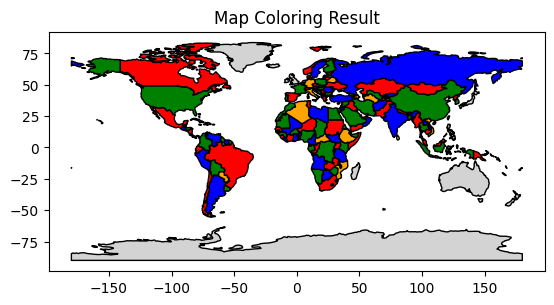

In [ ]:
import heapq
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
from collections import deque


# ---------------- BFS CYCLE FINDER ----------------
def bfs_find_smallest_cycles(graph):
    node_info = {
        node: {'cycle': None, 'visited': 0, 'color': 0, 'Available': {1, 2, 3}}
        for node in graph.nodes()
    }

    cycles = {}
    cycle_counter = 0

    def extract_cycle_path(u, v, parent):
        path_u, path_v = [], []

        while u is not None:
            path_u.append(u)
            u = parent.get(u)

        while v is not None:
            path_v.append(v)
            v = parent.get(v)

        set_u = set(path_u)
        lca = next((x for x in path_v if x in set_u), None)

        path1 = []
        x = path_u[0]
        while x != lca:
            path1.append(x)
            x = parent[x]
        path1.append(lca)

        path2 = []
        x = path_v[0]
        while x != lca:
            path2.append(x)
            x = parent[x]

        cycle = path1 + path2

        for n in cycle:
            if node_info[n]['cycle'] is not None:
                return None

        return cycle

    for start in graph.nodes():
        if node_info[start]['cycle'] is not None:
            continue

        queue = deque([start])
        parent = {start: None}
        visited_bfs = {start}

        while queue:
            u = queue.popleft()

            for v in graph.neighbors(u):
                if v == parent.get(u):
                    continue

                if v in visited_bfs:
                    cycle = extract_cycle_path(u, v, parent)
                    if cycle:
                        cycle_counter += 1
                        cycles[cycle_counter] = {'nodes': cycle, 'added': False}

                        for n in cycle:
                            node_info[n]['cycle'] = cycle_counter
                else:
                    visited_bfs.add(v)
                    parent[v] = u
                    queue.append(v)

    return cycles, node_info


# ---------------- COLORING ----------------
def three_coloring(cycles, node_info, graph):
    cycle_list = sorted(
        [(cid, len(cdata['nodes'])) for cid, cdata in cycles.items()],
        key=lambda x: x[1],
    )

    visited_cycle = {}
    cycle_heap = []

    def push_cycle(cid):
        heapq.heappush(cycle_heap, (-len(cycles[cid]['nodes']), cid))
        visited_cycle[cid] = True

    def build_node_heap(cycle_nodes):
        node_heap = []

        for node in cycle_nodes:
            for neigh in graph.neighbors(node):
                c = node_info[neigh]['color']
                if c != 0:
                    node_info[node]['Available'].discard(c)

            if not node_info[node]['Available']:
                return False, None

            heapq.heappush(node_heap, (len(node_info[node]['Available']), node))

        return True, node_heap

    while cycle_heap or cycle_list:

        if not cycle_heap:
            while cycle_list:
                cid, _ = cycle_list.pop()
                if not visited_cycle.get(cid):
                    push_cycle(cid)
                    break

        if not cycle_heap:
            break

        _, cid = heapq.heappop(cycle_heap)
        current_cycle = cycles[cid]['nodes']

        ok, node_heap = build_node_heap(current_cycle)
        if not ok:
            return False, node_info

        while node_heap:
            size, node = heapq.heappop(node_heap)

            if size != len(node_info[node]['Available']):
                continue
            if node_info[node]['color'] != 0:
                continue
            if not node_info[node]['Available']:
                return False, node_info

            color = min(node_info[node]['Available'])
            node_info[node]['color'] = color

            for neigh in graph.neighbors(node):
                if node_info[neigh]['color'] != 0:
                    continue

                if color in node_info[neigh]['Available']:
                    node_info[neigh]['Available'].discard(color)

                    if not node_info[neigh]['Available']:
                        return False, node_info

                    heapq.heappush(
                        node_heap,
                        (len(node_info[neigh]['Available']), neigh)
                    )

        for node in current_cycle:
            for neigh in graph.neighbors(node):
                neigh_cycle = node_info[neigh]['cycle']
                if neigh_cycle is not None and not visited_cycle.get(neigh_cycle):
                    push_cycle(neigh_cycle)

    return True, node_info


# ---------------- GRAPH FROM MAP ----------------
def build_country_graph(world):
    G = nx.Graph()

    for i in range(len(world)):
        G.add_node(i)

    for i, g1 in enumerate(world.geometry):
        for j, g2 in enumerate(world.geometry):
            if i >= j:
                continue
            if g1.touches(g2):
                G.add_edge(i, j)

    return G


# ---------------- VISUALIZATION ----------------
def plot_map(world, node_info):
    color_map = {
        1: "red",
        2: "green",
        3: "blue",
        4: "orange",
        0: "lightgray"
    }

    world["color"] = [
        color_map.get(node_info[i]['color'], "black") for i in range(len(world))
    ]

    world.plot(color=world["color"], edgecolor="black")
    plt.title("Map Coloring Result")
    plt.show()

def load_world():
    url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    return gpd.read_file(url)

# ---------------- MAIN ----------------

def main():
    world = load_world()
    G = build_country_graph(world)
    cycles, node_info = bfs_find_smallest_cycles(G)
    print(f"Cycles found: {len(cycles)}")
    ok, node_info = three_coloring(cycles, node_info, G)
    print("Coloring success:", ok)
    plot_map(world, node_info)


if __name__ == "__main__":
    main()

In [32]:

import heapq
import networkx as nx
from collections import deque

# ---------------- BFS CYCLE FINDER ----------------
def bfs_find_smallest_cycles(graph):
    node_info = {
        node: {'cycle': None, 'visited': 0, 'color': 0, 'Available': {1, 2 , 3}}
        for node in graph.nodes()
    }

    cycles = {}
    cycle_counter = 0

    def extract_cycle_path(u, v, parent):
        path_u, path_v = [], []

        while u is not None:
            path_u.append(u)
            u = parent.get(u)

        while v is not None:
            path_v.append(v)
            v = parent.get(v)

        set_u = set(path_u)
        lca = next((x for x in path_v if x in set_u), None)

        path1 = []
        x = path_u[0]
        while x != lca:
            path1.append(x)
            x = parent[x]
        path1.append(lca)

        path2 = []
        x = path_v[0]
        while x != lca:
            path2.append(x)
            x = parent[x]

        cycle = path1 + path2

        for n in cycle:
            if node_info[n]['cycle'] is not None:
                return None

        return cycle

    for start in graph.nodes():
        if node_info[start]['cycle'] is not None:
            continue

        queue = deque([start])
        parent = {start: None}
        visited_bfs = {start}

        while queue:
            u = queue.popleft()

            for v in graph.neighbors(u):
                if v == parent.get(u):
                    continue

                if v in visited_bfs:
                    cycle = extract_cycle_path(u, v, parent)
                    if cycle:
                        cycle_counter += 1
                        cycles[cycle_counter] = {'nodes': cycle, 'added': False}

                        for n in cycle:
                            node_info[n]['cycle'] = cycle_counter
                else:
                    visited_bfs.add(v)
                    parent[v] = u
                    queue.append(v)

    return cycles, node_info


# ---------------- COLORING ----------------
def three_coloring(cycles, node_info, graph):
    cycle_list = sorted(
        [(cid, len(cdata['nodes'])) for cid, cdata in cycles.items()],
        key=lambda x: x[1],
    )

    visited_cycle = {}
    cycle_heap = []

    def push_cycle(cid):
        heapq.heappush(cycle_heap, (-len(cycles[cid]['nodes']), cid))
        visited_cycle[cid] = True

    def build_node_heap(cycle_nodes):
        node_heap = []

        for node in cycle_nodes:
            for neigh in graph.neighbors(node):
                c = node_info[neigh]['color']
                if c != 0:
                    node_info[node]['Available'].discard(c)

            if not node_info[node]['Available']:
                return False, None

            heapq.heappush(node_heap, (len(node_info[node]['Available']), node))

        return True, node_heap

    while cycle_heap or cycle_list:

        if not cycle_heap:
            while cycle_list:
                cid, _ = cycle_list.pop()
                if not visited_cycle.get(cid):
                    push_cycle(cid)
                    break

        if not cycle_heap:
            break

        _, cid = heapq.heappop(cycle_heap)
        current_cycle = cycles[cid]['nodes']

        ok, node_heap = build_node_heap(current_cycle)
        if not ok:
            return False, node_info

        while node_heap:
            size, node = heapq.heappop(node_heap)

            if size != len(node_info[node]['Available']):
                continue
            if node_info[node]['color'] != 0:
                continue
            if not node_info[node]['Available']:
                return False, node_info

            color = min(node_info[node]['Available'])
            node_info[node]['color'] = color

            for neigh in graph.neighbors(node):
                if node_info[neigh]['color'] != 0:
                    continue

                if color in node_info[neigh]['Available']:
                    node_info[neigh]['Available'].discard(color)

                    if not node_info[neigh]['Available']:
                        return False, node_info

                    heapq.heappush(
                        node_heap,
                        (len(node_info[neigh]['Available']), neigh)
                    )

        for node in current_cycle:
            for neigh in graph.neighbors(node):
                neigh_cycle = node_info[neigh]['cycle']
                if neigh_cycle is not None and not visited_cycle.get(neigh_cycle):
                    push_cycle(neigh_cycle)

    return True, node_info

In [27]:
import matplotlib.pyplot as plt
import networkx as nx


def draw_colored_graph(G, node_info, title="Graph Coloring"):
    color_map = {
        1: "red",
        2: "green",
        3: "blue",
        0: "lightgray"
    }

    node_colors = [
        color_map[node_info[n]['color']]
        for n in G.nodes()
    ]

    pos = nx.spring_layout(G, seed=42)  # stable layout

    plt.figure(figsize=(10, 8))
    nx.draw(
        G,
        pos,
        node_color=node_colors,
        with_labels=False,
        node_size=50,
        edge_color="gray"
    )

    plt.title(title)
    plt.show()

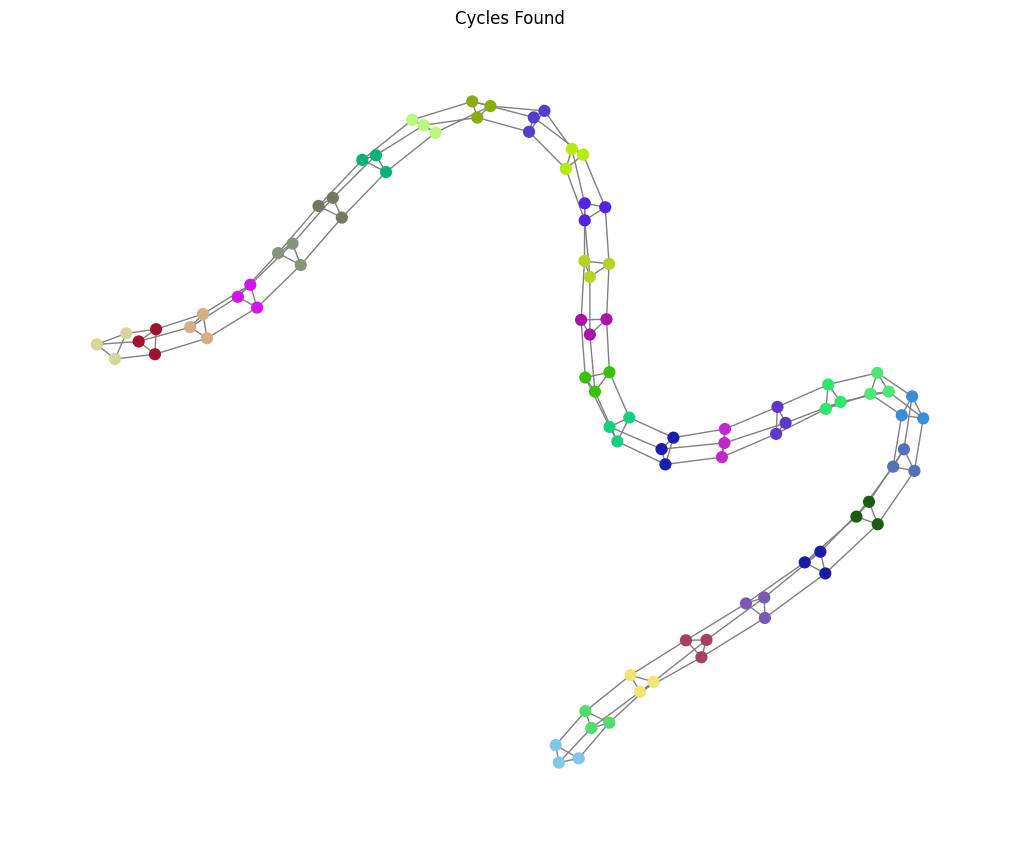

In [38]:
import matplotlib.pyplot as plt
import networkx as nx
import random


def draw_cycles_graph(G, cycles, node_info, title="Cycles Visualization"):
    """
    Visualize cycles + coloring:
    - Each cycle gets a distinct color
    - Unassigned nodes use coloring scheme
    """

    # generate unique color per cycle
    cycle_colors = {}
    for cid in cycles:
        cycle_colors[cid] = (
            random.random(),
            random.random(),
            random.random()
        )

    base_color_map = {
        1: "red",
        2: "green",
        3: "blue",
        0: "lightgray"
    }

    node_colors = []

    for node in G.nodes():
        cid = node_info[node]['cycle']

        if cid is not None and cid in cycle_colors:
            node_colors.append(cycle_colors[cid])  # highlight cycle
        else:
            node_colors.append(base_color_map[node_info[node]['color']])

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(10, 8))
    nx.draw(
        G,
        pos,
        node_color=node_colors,
        with_labels=False,
        node_size=60,
        edge_color="gray"
    )

    plt.title(title)
    plt.show()


# ---------------- USAGE ----------------
draw_cycles_graph(G, cycles, node_info, "Cycles Found")

In [14]:
import networkx as nx
import random


def generate_hard_3color(n=200, p=0.5):
    G = nx.Graph()

    partitions = {i: i % 3 for i in range(n)}
    G.add_nodes_from(range(n))

    for i in range(n):
        for j in range(i + 1, n):
            if partitions[i] != partitions[j] and random.random() < p:
                G.add_edge(i, j)

    return G

In [28]:
import networkx as nx
import random


def pigeonhole_3color(n=60, density=0.8):
    """
    Hard 3-colorable graph inspired by pigeonhole constraints
    """
    G = nx.Graph()

    # assign hidden true coloring
    true_color = {i: random.randint(1, 3) for i in range(n)}

    G.add_nodes_from(range(n))

    # add strong constraints
    for i in range(n):
        for j in range(i + 1, n):

            # forbid same color edges (normal coloring constraint)
            if true_color[i] == true_color[j]:
                continue

            # add many cross edges (tight constraint)
            if random.random() < density:
                G.add_edge(i, j)

    return G, true_color

In [36]:
def pigeonhole_chain(n=90):
    G = nx.Graph()

    # groups of 3 → force color cycling
    for i in range(0, n, 3):
        a, b, c = i, i+1, i+2

        G.add_edges_from([
            (a, b), (b, c), (c, a)  # triangle = forces 3 colors
        ])

        if i > 0:
            # connect to previous group (propagation constraint)
            G.add_edge(i, i-1)
            G.add_edge(i+1, i-2)
            G.add_edge(i+2, i-3)

    return G

Cycles found: 30
3-color success: True
Colors used: {1, 2, 3}


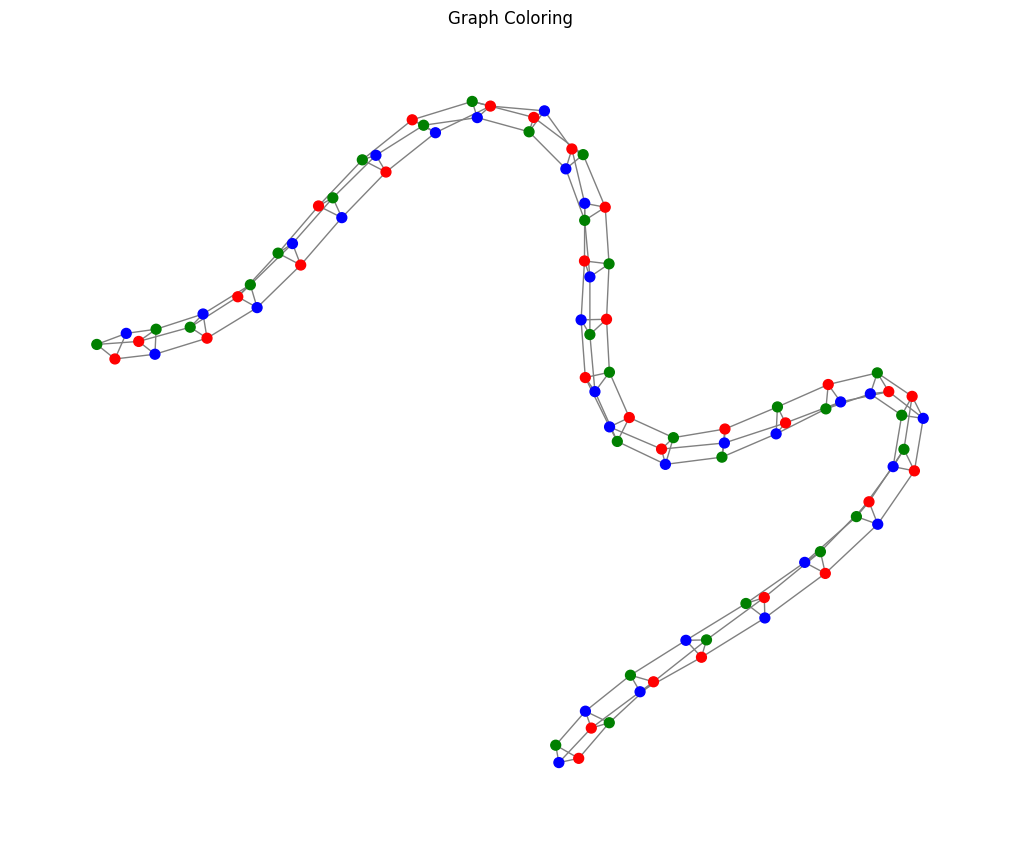

In [37]:
#G=generate_hard_3color()
#G,_ = pigeonhole_3color(40, 0.7)
G= pigeonhole_chain()
cycles, node_info = bfs_find_smallest_cycles(G)

print("Cycles found:", len(cycles))

ok, node_info = three_coloring(cycles, node_info, G)

print("3-color success:", ok)

if ok:
    colors = {node_info[n]['color'] for n in G.nodes()}
    print("Colors used:", colors)
else:
    print("not 3 colorable")
draw_colored_graph(G, node_info)

In [18]:
import networkx as nx
import urllib.request


def load_dimacs_col_from_url(url):
    G = nx.Graph()

    with urllib.request.urlopen(url) as f:
        for raw in f:
            line = raw.decode("utf-8").strip()

            if not line or line.startswith("c"):
                continue

            if line.startswith("p"):
                _, _, n, _ = line.split()
                G.add_nodes_from(range(1, int(n) + 1))

            elif line.startswith("e"):
                _, u, v = line.split()
                G.add_edge(int(u), int(v))

    return G


def main():
    url = "https://mat.tepper.cmu.edu/COLOR/instances/myciel2.col"

    G = load_dimacs_col_from_url(url)

    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())

    cycles, node_info = bfs_find_smallest_cycles(G)

    print("Cycles found:", len(cycles))

    ok, node_info = three_coloring(cycles, node_info, G)

    print("3-color success:", ok)

    if ok:
        colors = {node_info[n]['color'] for n in G.nodes()}
        print("Colors used:", colors)
    else:
        print("not 3 colorable")


if __name__ == "__main__":
    main()

Nodes: 0
Edges: 0
Cycles found: 0
3-color success: True
Colors used: set()
